# Prac W2 - Supervised Learning (k-NN and Decision Trees)

### Aims:

- To apply k-NN and decision trees as examples of supervised learning models for classification 
and regression problems 
- To get some insight into the trained models, including the infleunce of a hyperparameter in an ML
model
- To produce some assessable work for this project 

### (**Q1**) Make scatter plots of each dataset so you can see what they look like

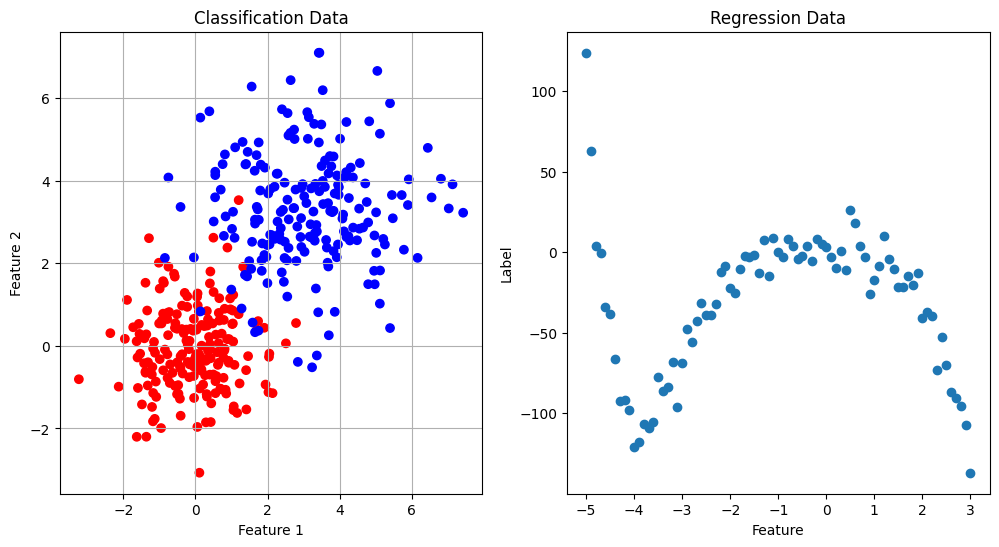

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from __future__ import annotations

from typing import Tuple

W3CLASSIF_FILEPATH: str = "./datasets/w3classif.csv"
W3REGR_FILEPATH: str = "./datasets/w3regr.csv"

def load_data() -> Tuple[pd.DataFrame, pd.DataFrame]:
    return (
        pd.read_csv(W3CLASSIF_FILEPATH, sep=",", header=None), 
        pd.read_csv(W3REGR_FILEPATH, sep=",", header=None)
    )

def generate_scatterplots(data: Tuple[pd.DataFrame, pd.DataFrame]) -> None:
    fix, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,6))

    # For Classfication data, use first two features for x and y values and label as colour
    classif_data: pd.DataFrame = data[0]
    markers: pd.Series = classif_data.iloc[:, 2].map({ 0: 'red', 1: 'blue' })

    axs[0].set_title("Classification Data")
    axs[0].set_xlabel("Feature 1")
    axs[0].set_ylabel("Feature 2")
    axs[0].scatter(classif_data.iloc[:, 0], classif_data.iloc[:, 1], color=markers)
    axs[0].grid(True)

    # For regression data, use first column for feature, use second column for label
    regr_data: pd.DataFrame = data[1]

    axs[1].set_title("Regression Data")
    axs[1].set_xlabel("Feature")
    axs[1].set_ylabel("Label")
    axs[1].scatter(regr_data.iloc[:, 0], regr_data.iloc[:, 1])

    plt.show()


dfs: Tuple[pd.DataFrame, pd.DataFrame] = load_data()
generate_scatterplots(dfs)


### (**Q2**) Randomly shuffle the datasets (i.e. the order of the rows) and split them each into 
### 70% training and 30% for testing

In [ ]:
from sklearn.model_selection import train_test_split

classif_x_train, classif_x_test, classif_y_train, classif_y_test = train_test_split(
    dfs[0].iloc[:, : 2].values, dfs[0].iloc[:, 2].values, test_size=0.3, random_state=67
)

regr_x_train, regr_x_test, regr_y_train, regr_y_test = train_test_split(
    dfs[1].iloc[:, 0].values, dfs[1].iloc[:, 1].values, test_size=0.3, random_state=67
)

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: 2, Length: 400, dtype: int64


### (**Q3a**) Build a k-NN classific with k = 3 for dataset w3classif.csv and find the 
### training and test loss (i.e missclassfication rate)

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

def build_knn_classifier(x_train, y_train, x_test, y_test, k) -> None:
    # Standardise Values
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    model.fit(x_train, y_train)
    y_train_pred = model.predict(x_train)

    train_loss: float = accuracy_score(y_train, y_train_pred)

    print(f"KNN Classifier (k = {k}) Train Loss: {train_loss:.2f}")

    y_test_pred = model.predict(x_test)

    test_loss: float = accuracy_score(y_test, y_test_pred)

    print(f"KNN Classifier (k = {k}) Test Loss: {test_loss:.2f}")

build_knn_classifier(classif_x_train, classif_y_train, classif_x_test, classif_y_test, 3)


KNN Classifier (k = 3) Train Loss: 0.96
KNN Classifier (k = 3) Test Loss: 0.99
